# Topic: Imbalanced data, Evaluation metrics, Cross validation
數據不平衡，評估指標，交叉驗證

TA imformation <br>
江彥霖 宏裕科技大樓 434 <br>
email: t108378006@ntut.org.tw

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
from sklearn import preprocessing
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import recall_score, precision_score
from sklearn import svm

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

import random

# Load data

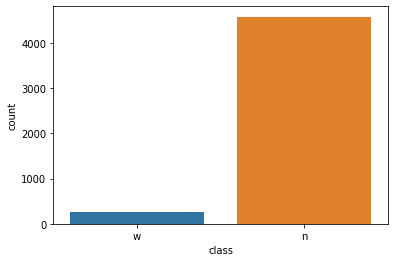

In [ ]:
wilt_all = pd.read_csv('wilt_all.csv')
ax = sns.countplot(x="class", data=wilt_all)

In [ ]:
print('n class:', sum(wilt_all['class']=='n'))
print('w class:', sum(wilt_all['class']=='w'))
print('n ratio:', sum(wilt_all['class']=='n')/len(wilt_all))
print('w ratio:', sum(wilt_all['class']=='w')/len(wilt_all))

n class: 4578
w class: 261
n ratio: 0.9460632362058277
w ratio: 0.05393676379417235


# Split data to train and test (HW-1)

HW1可參考此流程，就能夠正確依照原資料比例切出

In [ ]:
train_ratio = 0.8
num_data = len(wilt_all)
train_len = int(num_data * train_ratio)
test_len = num_data - train_len

1. 創建與資料比數一樣的list [0~n]
2. 創建空的dataframe
3. 當count<train_len，將train_df與pd.DataFrame(wilt_all.iloc[i]).T concat在一起
4. 當count>train_len，將test_df與pd.DataFrame(wilt_all.iloc[i]).T concat在一起

In [ ]:
init_list = list(range(num_data))
random.shuffle(init_list)

train_df = pd.DataFrame()
test_df = pd.DataFrame()

count=0
for i in init_list:
    if count < train_len:
        train_df = pd.concat([train_df, pd.DataFrame(wilt_all.iloc[i]).T], axis=0).reset_index(drop=True)
        count+=1
    else:
        test_df = pd.concat([test_df, pd.DataFrame(wilt_all.iloc[i]).T], axis=0).reset_index(drop=True)
        count+=1

In [ ]:
y_train = train_df['class']
x_train = train_df.drop(['class'],axis=1)
y_test = test_df['class']
x_test = test_df.drop(['class'],axis=1)

In [ ]:
le = LabelEncoder()
le.fit(['n','w'])
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [ ]:
print('y_train class n:', sum(y_train==0))
print('y_train class w:', sum(y_train==1))
print('y_train ratio n:', sum(y_train==0)/len(y_train))
print('y_train ratio w:', sum(y_train==1)/len(y_train))
print('-------------------------------------------------')
print('y_test class n:', sum(y_test==0))
print('y_test class w:', sum(y_test==1))
print('y_test ratio n:', sum(y_test==0)/len(y_test))
print('y_test ratio w:', sum(y_test==1)/len(y_test))

y_train class n: 3668
y_train class w: 203
y_train ratio n: 0.9475587703435805
y_train ratio w: 0.05244122965641953
-------------------------------------------------
y_test class n: 910
y_test class w: 58
y_test ratio n: 0.9400826446280992
y_test ratio w: 0.05991735537190083


利用train_test_split將資料切分成train, test

In [ ]:
wilt_all = pd.read_csv('wilt_all.csv')
labels = wilt_all['class']
wilt_all = wilt_all.drop(['class'],axis=1)
right_ratio_x_train, right_ratio_x_test, right_ratio_y_train, right_ratio_y_test = train_test_split(wilt_all, labels, test_size=0.2, random_state=666)

In [ ]:
right_ratio_y_train = le.transform(right_ratio_y_train)
right_ratio_y_test = le.transform(right_ratio_y_test)

In [ ]:
print('right_ratio_y_train class n:', sum(right_ratio_y_train==0))
print('right_ratio_y_train class w:', sum(right_ratio_y_train==1))
print('right_ratio_y_train ratio n:', sum(right_ratio_y_train==0)/len(right_ratio_y_train))
print('right_ratio_y_train ratio w:', sum(right_ratio_y_train==1)/len(right_ratio_y_train))
print('------------------------------------------')
print('right_ratio_y_test class n:', sum(right_ratio_y_test==0))
print('right_ratio_y_test class w:', sum(right_ratio_y_test==1))
print('right_ratio_y_test ratio n:', sum(right_ratio_y_test==0)/len(right_ratio_y_test))
print('right_ratio_y_test ratio w:', sum(right_ratio_y_test==1)/len(right_ratio_y_test))

right_ratio_y_train class n: 3656
right_ratio_y_train class w: 215
right_ratio_y_train ratio n: 0.9444587961766985
right_ratio_y_train ratio w: 0.05554120382330147
------------------------------------------
right_ratio_y_test class n: 922
right_ratio_y_test class w: 46
right_ratio_y_test ratio n: 0.9524793388429752
right_ratio_y_test ratio w: 0.047520661157024795


# Data normalization

資料標準化

In [ ]:
def normalize(x_train, x_test, method = 'StandardScaler'):
    '''
    method = 'StandardScaler', 'PowerTransformer', 'MinMaxScaler'
    '''    
    if method == 'StandardScaler':
        normalize_function = preprocessing.StandardScaler()
    if method == 'PowerTransformer':
        normalize_function = preprocessing.PowerTransformer(method='yeo-johnson', standardize=True) # yeo-johnson, box-cox     
    if method == 'MinMaxScaler':
        normalize_function = preprocessing.MinMaxScaler()
    
    features = x_train.columns
    for feature in features:
        reshape = np.array(x_train[feature]).reshape(-1, 1)
        x_train[feature] = normalize_function.fit_transform(reshape)

        reshape = np.array(x_test[feature]).reshape(-1, 1)
        x_test[feature] = normalize_function.transform(reshape)
    
    return x_train, x_test

right_ratio_x_train, right_ratio_x_test = normalize(right_ratio_x_train, right_ratio_x_test)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

# Evaluation metrics (HW-2)

Accuracy<br>
Recall = TP / (TP + FN)<br>
召回率 (Recall)：正樣本有多少被找出来(召回了多少)<br>
Precision = TP / (TP + FP)<br>
精確率 (Precision)：模型認為的正樣本，有多少預測對了(預測的精確性如何)<br>
F1-score = 2 * Precision * Recall / (Precision + Recall)

In [ ]:
def plot_CM(true_label, pred_label, title):
    
    # Creates a confusion matrix
    cm = confusion_matrix(true_label, pred_label) 

    # Transform to df for easier plotting
    cm_df = pd.DataFrame(cm,index = ['n', 'w'], columns = ['n', 'w'])
    plt.figure(figsize=(5.5,4))
    sns.heatmap(cm_df, annot=True, fmt="d")
    acc = accuracy_score(true_label, pred_label)

    recall = recall_score(true_label, pred_label, pos_label='n')
    precision = precision_score(true_label, pred_label, pos_label='n')

    plt.title(title + '\nAccuracy:{0:.3f}\nRecall:{1:.3f}\nPrecision:{2:.3f}'.format(acc, recall, precision))
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Naive bayes model (Supervised model)

In [ ]:
NB_model = GaussianNB()
NB_model.fit(right_ratio_x_train, right_ratio_y_train)

y_pred = NB_model.predict(right_ratio_x_test)

In [ ]:
y_pred = le.inverse_transform(y_pred)
out_y_test = le.inverse_transform(right_ratio_y_test)

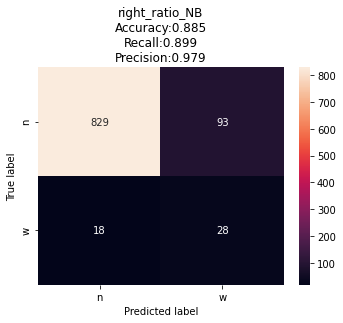

In [ ]:
plot_CM(out_y_test, y_pred, 'right_ratio_NB') 

# Up sampling
以上採樣增加類別較少的資料量

In [ ]:
up_sample_x, up_sample_y = right_ratio_x_train, right_ratio_y_train
print('before sampling=', up_sample_x.shape, up_sample_y.shape)
upsample = RandomOverSampler(random_state=1)
up_sample_x, up_sample_y = upsample.fit_resample(up_sample_x, up_sample_y)
print('after sampling=', up_sample_x.shape, up_sample_y.shape)

before sampling= (3871, 5) (3871,)
after sampling= (7312, 5) (7312,)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function safe_indexing is deprecated; safe_indexing is deprecated in version 0.22 and will be removed in version 0.24.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
print('Before upsampling 0: ',sum(right_ratio_y_train==0))
print('Before upsampling 1: ',sum(right_ratio_y_train==1))
print('------------------------------------------')
print('After upsampling 0: ',sum(up_sample_y==0))
print('After upsampling 1: ',sum(up_sample_y==1))

Before upsampling 0:  3656
Before upsampling 1:  215
------------------------------------------
After upsampling 0:  3656
After upsampling 1:  3656


In [ ]:
NB_model = GaussianNB()
NB_model.fit(up_sample_x, up_sample_y)

y_pred = NB_model.predict(right_ratio_x_test)

In [ ]:
y_pred = le.inverse_transform(y_pred)
out_y_test = le.inverse_transform(right_ratio_y_test)

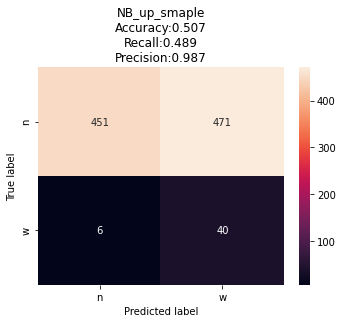

In [ ]:
plot_CM(out_y_test, y_pred, 'NB_up_smaple')

# Down sampling
以下採樣降低類別較多的資料量

In [ ]:
down_sample_x, down_sample_y = right_ratio_x_train, right_ratio_y_train
print('before sampling=', down_sample_x.shape, down_sample_y.shape)
undersample = RandomUnderSampler(sampling_strategy='majority', random_state=1)
down_sample_x, down_sample_y = undersample.fit_resample(down_sample_x, down_sample_y)
print('after sampling=', down_sample_x.shape, down_sample_y.shape)

before sampling= (3871, 5) (3871,)
after sampling= (430, 5) (430,)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function safe_indexing is deprecated; safe_indexing is deprecated in version 0.22 and will be removed in version 0.24.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
print('Before downsampling 0: ',sum(right_ratio_y_train==0))
print('Before downsampling 1: ',sum(right_ratio_y_train==1))
print('------------------------------------------')
print('After downsampling 0: ',sum(down_sample_y==0))
print('After downsampling 1: ',sum(down_sample_y==1))

Before downsampling 0:  3656
Before downsampling 1:  215
------------------------------------------
After downsampling 0:  215
After downsampling 1:  215


In [ ]:
NB_model = GaussianNB()
NB_model.fit(down_sample_x, down_sample_y)

y_pred = NB_model.predict(right_ratio_x_test)

In [ ]:
y_pred = le.inverse_transform(y_pred)
out_y_test = le.inverse_transform(right_ratio_y_test)

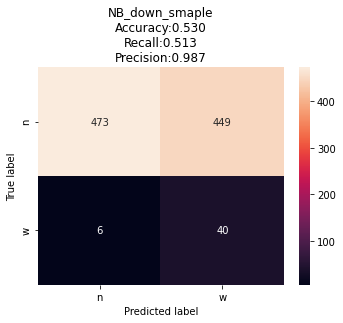

In [ ]:
plot_CM(out_y_test, y_pred, 'NB_down_smaple')

# One class SVM (Unsupervised model)

![jupyter](./unsupercised.png)

In [ ]:
wilt_all = pd.read_csv('wilt_all.csv')
n_data = wilt_all[wilt_all['class'] == 'n']
w_data = wilt_all[wilt_all['class'] == 'w']
n_label = n_data['class']
w_label = w_data['class']
del n_data['class']; del w_data['class']

In [ ]:
# split to train test
n_x_train, n_x_test, n_y_train, n_y_test = train_test_split(n_data, n_label, test_size=0.2, random_state=150)

In [ ]:
# concat test data, normalize train, test specifically
X_test = pd.concat([n_x_test, w_data], axis = 0)
X_test = X_test.reset_index(drop = True)

total_label = pd.concat([n_y_test, w_label], axis = 0)

In [ ]:
out_x_train, out_x_test = normalize(n_x_train, X_test)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

In [ ]:
# train model
nu=len(w_data)/len(wilt_all)
# fit the model
clf = svm.OneClassSVM(nu=nu, kernel='rbf')
clf.fit(out_x_train)

OneClassSVM(cache_size=200, coef0=0.0, degree=3, gamma='scale', kernel='rbf',
            max_iter=-1, nu=0.05393676379417235, shrinking=True, tol=0.001,
            verbose=False)

In [ ]:
# pred test
y_pred = clf.predict(out_x_test)

In [ ]:
y_pred = y_pred.astype(str)
y_pred[y_pred=='1'] = 'n'
y_pred[y_pred=='-1'] = 'w'

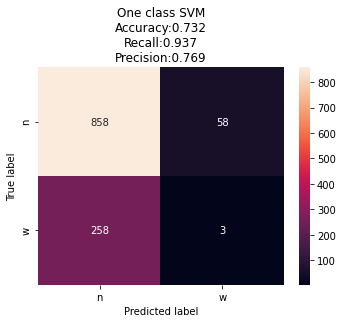

In [ ]:
plot_CM(total_label, y_pred, 'One class SVM')

# K-fold Cross validation

一般來說我們在做機器學習 ( Machine Learning ) 的時候，我們會習慣將資料集 ( Dataset ) 切割 ( Splits ) 成訓練集 ( Training Set ) 跟驗證集 ( Validation Set )。顧名思義，Training Set是用來訓練 Machine Learning 的 Model；而 Validation Set 則用來驗證這個 Model 訓練的好不好。

![jupyter](./cross_validation.png)

K-fold Cross-Validation 就是將資料集拆分成 K 份做交叉驗證。<br>
交叉驗證的方法是將其中 K-1 份的資料當作訓練集，剩下來的那份做為驗證集，算出一個 Validation loss，<br>
接著再從沒當過驗證集的資料挑一份出來當驗證集，剛剛做過驗證集的資料則加回訓練集，<br>
維持 K-1 份做訓練、1 份做驗證，如此反覆直到每一份資料都當過驗證集，<br>
這樣會執行 K 次，算出 K 個 Validation loss，最後我們再將這 K 個 Validation loss 做平均，<br>
用他們的平均分數來做為我們評斷模型好壞的指標。

能夠利用cross validation計算模型之表現，看模型表現是否平均

In [ ]:
NB_model = GaussianNB()
scores = cross_val_score(NB_model, right_ratio_x_train, right_ratio_y_train, cv=5, scoring='f1')
scores

array([0.28767123, 0.4       , 0.36363636, 0.33766234, 0.34328358])